

MSc Data Science and AI Dissertation
- **SSIM score**  — structural similarity of the incoming frame vs a clean reference
- **CNN confidence score**  — how certain the terrain classifier is about its prediction

### Trigger Rule
Replanning is triggered when **either** signal drops below its threshold — whichever degrades first.

### Severity Levels
| Level | Condition | Action |
|-------|-----------|--------|
| **Clean** | SSIM ≥ 0.7 AND confidence ≥ 0.6 | Navigate normally |
| **Degraded** | SSIM 0.4–0.7 OR confidence 0.4–0.6 | Increase terrain uncertainty, soft replan |
| **Critical** | SSIM < 0.4 OR confidence < 0.4 | Immediate replan with maximum uncertainty |



## Step 1 — Install & Import Dependencies

In [ ]:
!pip install scikit-image -q

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
from torchvision import models, transforms
from skimage.metrics import structural_similarity as ssim
from PIL import Image
import cv2
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda



##  Step 2 — Load Trained CNN from Notebook 03

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


CHECKPOINT_PATH = '/content/drive/MyDrive/Colab Notebooks/Mars Rover Project/terrain_classifier.pth'

checkpoint   = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
CLASS_NAMES  = checkpoint['class_names']
NUM_CLASSES  = checkpoint['num_classes']
IMG_SIZE     = checkpoint['img_size']
IMAGENET_MEAN = checkpoint['imagenet_mean']
IMAGENET_STD  = checkpoint['imagenet_std']

# Rebuild model architecture
model = models.resnet18(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, NUM_CLASSES)
)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print(f'Model loaded successfully.')
print(f'Classes: {CLASS_NAMES}')
print(f'Validation accuracy: {checkpoint["val_accuracy"]*100:.2f}%')

Model loaded successfully.
Classes: ['bright dune', 'crater', 'dark dune', 'impact ejecta', 'other', 'slope streak', 'spider', 'swiss cheese']
Validation accuracy: 91.71%


##  Step 3 — Degradation Functions

In [ ]:
def apply_gaussian_noise(frame, severity=0.3, seed=None):
    rng = np.random.default_rng(seed)
    noise = rng.normal(0, severity * 80, frame.shape)
    return np.clip(frame.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def apply_occlusion(frame, severity=0.3, seed=None):
    rng = np.random.default_rng(seed)
    degraded = frame.copy()
    h, w = frame.shape[:2]
    occ_h, occ_w = int(h * severity * 0.9), int(w * severity * 0.9)
    if occ_h > 0 and occ_w > 0:
        top  = rng.integers(0, max(1, h - occ_h))
        left = rng.integers(0, max(1, w - occ_w))
        degraded[top:top+occ_h, left:left+occ_w] = 160
    return degraded

def apply_dropout(frame, severity=0.3, seed=None):
    rng = np.random.default_rng(seed)
    degraded = frame.copy()
    mask = rng.random(frame.shape[:2]) < severity
    degraded[mask] = 0
    return degraded

DEGRADATION_FNS = {
    'Gaussian Noise': apply_gaussian_noise,
    'Occlusion':      apply_occlusion,
    'Dropout':        apply_dropout,
}

print('Degradation functions ready.')

Degradation functions ready.


##  Step 4 — Sensor Quality Monitor

The monitor combines SSIM and CNN confidence into a single severity classification.

**Trigger rule:** replanning fires when **either** signal drops below threshold.
This makes the system responsive to whichever degradation type affects quality first.

In [ ]:
#  Thresholds
SSIM_CLEAN     = 0.7   # SSIM above this → clean
SSIM_DEGRADED  = 0.4   # SSIM between 0.4-0.7 → degraded
                        # SSIM below 0.4 → critical

CONF_CLEAN     = 0.6   # Confidence above this → clean
CONF_DEGRADED  = 0.4   # Confidence between 0.4-0.6 → degraded
                        # Confidence below 0.4 → critical

# Severity levels
CLEAN    = 'Clean'
DEGRADED = 'Degraded'
CRITICAL = 'Critical'

# Uncertainty cost multipliers applied to terrain grid during replanning
UNCERTAINTY_MULTIPLIER = {
    CLEAN:    1.0,   # No change to terrain costs
    DEGRADED: 2.0,   # Double the cost of uncertain cells
    CRITICAL: 5.0,   # 5x cost — treat most terrain as risky
}

SEVERITY_COLOURS = {
    CLEAN:    '#1D9E75',
    DEGRADED: '#FFC107',
    CRITICAL: '#E05C5C',
}


def compute_ssim(clean_frame, degraded_frame):
    """Compute SSIM between clean reference and degraded frame."""
    clean_grey    = cv2.cvtColor(clean_frame,    cv2.COLOR_RGB2GRAY) if clean_frame.ndim == 3 else clean_frame
    degraded_grey = cv2.cvtColor(degraded_frame, cv2.COLOR_RGB2GRAY) if degraded_frame.ndim == 3 else degraded_frame
    return ssim(clean_grey, degraded_grey, data_range=255)


def get_cnn_confidence(frame, model, transform):
    """Run CNN inference and return predicted class and confidence score."""
    pil_img = Image.fromarray(frame).convert('RGB')
    tensor  = transform(pil_img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)
        conf, pred = probs.max(dim=1)
    return pred.item(), conf.item()


def assess_severity(ssim_score, cnn_confidence):
    """
    Classify sensor quality into Clean, Degraded, or Critical.

    Trigger rule: EITHER signal dropping below threshold is sufficient
    to escalate severity — the worse of the two signals governs.

    Args:
        ssim_score:     SSIM score (0-1)
        cnn_confidence: CNN confidence score (0-1)

    Returns:
        severity: CLEAN, DEGRADED, or CRITICAL
        replan:   True if replanning should be triggered
    """
    # Critical if either signal is critically low
    if ssim_score < SSIM_DEGRADED or cnn_confidence < CONF_DEGRADED:
        return CRITICAL, True

    # Degraded if either signal is below clean threshold
    if ssim_score < SSIM_CLEAN or cnn_confidence < CONF_CLEAN:
        return DEGRADED, True

    # Both signals above threshold
    return CLEAN, False


def monitor_frame(clean_frame, degraded_frame, model, transform):
    """
    Full sensor quality monitor pipeline for a single frame.

    Args:
        clean_frame:    reference clean frame (numpy array)
        degraded_frame: incoming potentially degraded frame
        model:          trained CNN terrain classifier
        transform:      val transform for CNN input

    Returns:
        dict with ssim, confidence, severity, replan, uncertainty_multiplier
    """
    ssim_score  = compute_ssim(clean_frame, degraded_frame)
    pred, conf  = get_cnn_confidence(degraded_frame, model, transform)
    severity, replan = assess_severity(ssim_score, conf)

    return {
        'ssim':                 round(ssim_score, 4),
        'cnn_confidence':       round(conf, 4),
        'predicted_class':      CLASS_NAMES[pred],
        'severity':             severity,
        'replan':               replan,
        'uncertainty_multiplier': UNCERTAINTY_MULTIPLIER[severity],
    }


print('Sensor Quality Monitor defined.')
print(f'  SSIM thresholds:       Clean ≥ {SSIM_CLEAN} | Degraded {SSIM_DEGRADED}-{SSIM_CLEAN} | Critical < {SSIM_DEGRADED}')
print(f'  Confidence thresholds: Clean ≥ {CONF_CLEAN} | Degraded {CONF_DEGRADED}-{CONF_CLEAN} | Critical < {CONF_DEGRADED}')
print(f'  Trigger rule:          EITHER signal dropping below threshold triggers escalation')

Sensor Quality Monitor defined.
  SSIM thresholds:       Clean ≥ 0.7 | Degraded 0.4-0.7 | Critical < 0.4
  Confidence thresholds: Clean ≥ 0.6 | Degraded 0.4-0.6 | Critical < 0.4
  Trigger rule:          EITHER signal dropping below threshold triggers escalation


##  Step 5 — Test Monitor on Single Frames

In [ ]:
# Load sample images from the dataset
DATA_ROOT = '/content/drive/MyDrive/Colab Notebooks/Mars Rover Project/mars_terrain/Auburn_1'

# Pick one image per class for testing
sample_images = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATA_ROOT, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if files:
        img = np.array(Image.open(os.path.join(cls_path, files[0])).convert('RGB'))
        sample_images[cls] = img

# Test monitor on a crater image with increasing dropout severity
test_class  = 'crater'
clean_frame = sample_images[test_class]

print(f'Testing monitor on: {test_class}')
print(f'{"-"*75}')
print(f'{"Severity":>12} | {"SSIM":>8} | {"CNN Conf":>10} | {"Status":>10} | {"Replan":>8} | {"Uncertainty":>12}')
print(f'{"-"*75}')

for sev in [0.0, 0.2, 0.4, 0.6, 0.8]:
    if sev == 0.0:
        frame = clean_frame
    else:
        frame = apply_dropout(clean_frame, severity=sev, seed=42)

    result = monitor_frame(clean_frame, frame, model, val_transform)
    print(f'{sev:>12.1f} | {result["ssim"]:>8.4f} | {result["cnn_confidence"]:>10.4f} | '
          f'{result["severity"]:>10} | {str(result["replan"]):>8} | {result["uncertainty_multiplier"]:>12.1f}x')

Testing monitor on: crater
---------------------------------------------------------------------------
    Severity |     SSIM |   CNN Conf |     Status |   Replan |  Uncertainty
---------------------------------------------------------------------------
         0.0 |   1.0000 |     0.9953 |      Clean |    False |          1.0x
         0.2 |   0.1323 |     0.5200 |   Critical |     True |          5.0x
         0.4 |   0.0771 |     0.6839 |   Critical |     True |          5.0x
         0.6 |   0.0468 |     0.6583 |   Critical |     True |          5.0x
         0.8 |   0.0245 |     0.8049 |   Critical |     True |          5.0x


##  Step 6 — Monitor Decision Map

For every combination of degradation type and severity level, show what decision the monitor makes.


In [ ]:
SEVERITY_RANGE = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
TEST_CLASS     = 'crater'
clean_frame    = sample_images[TEST_CLASS]

all_results = {}

for deg_name, deg_fn in DEGRADATION_FNS.items():
    results = []
    for sev in SEVERITY_RANGE:
        frame = clean_frame if sev == 0.0 else deg_fn(clean_frame, severity=sev, seed=42)
        r = monitor_frame(clean_frame, frame, model, val_transform)
        r['severity_input'] = sev
        results.append(r)
    all_results[deg_name] = results

# Print summary table
for deg_name, results in all_results.items():
    print(f'\n{deg_name}')
    print(f'  {"Severity":>8} | {"SSIM":>8} | {"CNN Conf":>10} | {"Status":>10} | {"Replan":>8}')
    print(f'  {"-"*55}')
    for r in results:
        print(f'  {r["severity_input"]:>8.1f} | {r["ssim"]:>8.4f} | {r["cnn_confidence"]:>10.4f} | '
              f'{r["severity"]:>10} | {str(r["replan"]):>8}')


Gaussian Noise
  Severity |     SSIM |   CNN Conf |     Status |   Replan
  -------------------------------------------------------
       0.0 |   1.0000 |     0.9953 |      Clean |    False
       0.1 |   0.8483 |     0.8731 |      Clean |    False
       0.2 |   0.6151 |     0.2617 |   Critical |     True
       0.3 |   0.4468 |     0.2363 |   Critical |     True
       0.4 |   0.3370 |     0.2560 |   Critical |     True
       0.5 |   0.2638 |     0.2081 |   Critical |     True
       0.6 |   0.2132 |     0.1848 |   Critical |     True
       0.7 |   0.1772 |     0.2540 |   Critical |     True
       0.8 |   0.1508 |     0.3215 |   Critical |     True

Occlusion
  Severity |     SSIM |   CNN Conf |     Status |   Replan
  -------------------------------------------------------
       0.0 |   1.0000 |     0.9953 |      Clean |    False
       0.1 |   0.9910 |     0.9952 |      Clean |    False
       0.2 |   0.9766 |     0.9953 |      Clean |    False
       0.3 |   0.9549 |     0.9

##  Step 7 — Monitor Decision Visualisation

Visual heatmap of severity decisions across all degradation types and severity levels.

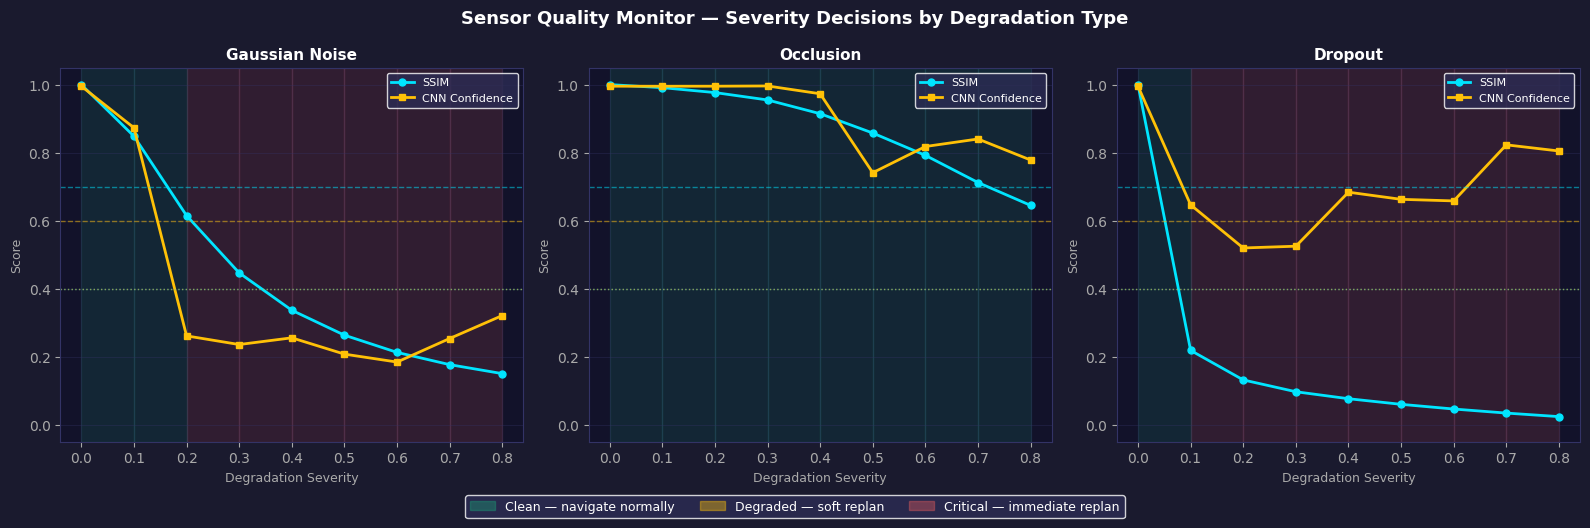

Saved to Drive.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#1A1A2E')
fig.suptitle('Sensor Quality Monitor — Severity Decisions by Degradation Type',
             color='white', fontsize=13, fontweight='bold')

severity_to_num = {CLEAN: 0, DEGRADED: 1, CRITICAL: 2}
colours         = ['#1D9E75', '#FFC107', '#E05C5C']

for ax, (deg_name, results) in zip(axes, all_results.items()):
    ax.set_facecolor('#12122A')

    severities = [r['severity_input'] for r in results]
    ssim_vals  = [r['ssim']           for r in results]
    conf_vals  = [r['cnn_confidence'] for r in results]
    decisions  = [r['severity']       for r in results]
    colours_bar = [SEVERITY_COLOURS[d] for d in decisions]

    ax.plot(severities, ssim_vals, color='#00E5FF', linewidth=2,
            marker='o', markersize=5, label='SSIM')
    ax.plot(severities, conf_vals, color='#FFC107', linewidth=2,
            marker='s', markersize=5, label='CNN Confidence')

    # Shade background by severity decision
    for i, (sev, decision) in enumerate(zip(severities, decisions)):
        if i < len(severities) - 1:
            ax.axvspan(severities[i], severities[i+1],
                       alpha=0.15, color=SEVERITY_COLOURS[decision])

    ax.axhline(SSIM_CLEAN,    color='#00E5FF', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(SSIM_DEGRADED, color='#00E5FF', linestyle=':',  linewidth=1, alpha=0.5)
    ax.axhline(CONF_CLEAN,    color='#FFC107', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(CONF_DEGRADED, color='#FFC107', linestyle=':',  linewidth=1, alpha=0.5)

    ax.set_title(deg_name, color='white', fontsize=11, fontweight='bold')
    ax.set_xlabel('Degradation Severity', color='#AAAAAA', fontsize=9)
    ax.set_ylabel('Score', color='#AAAAAA', fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(colors='#AAAAAA')
    ax.grid(True, color='#333366', linewidth=0.5, alpha=0.5)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333366')
    ax.legend(facecolor='#2C2C54', edgecolor='white', labelcolor='white', fontsize=8)

# Severity legend
legend_patches = [
    mpatches.Patch(color='#1D9E75', alpha=0.4, label='Clean — navigate normally'),
    mpatches.Patch(color='#FFC107', alpha=0.4, label='Degraded — soft replan'),
    mpatches.Patch(color='#E05C5C', alpha=0.4, label='Critical — immediate replan'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           facecolor='#2C2C54', edgecolor='white', labelcolor='white',
           fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = os.path.dirname('/content/drive/MyDrive/Colab Notebooks/Mars Rover Project/figures/nb04_monitor_decisions.png')
os.makedirs(output_dir, exist_ok=True)

plt.savefig('/content/drive/MyDrive/Colab Notebooks/Mars Rover Project/figures/nb04_monitor_decisions.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved to Drive.')


## Step 8 — Simulating a Live Feed with Monitor Active

Simulate a sequence of frames where degradation increases over time.
The monitor watches each frame and flags when to replan.

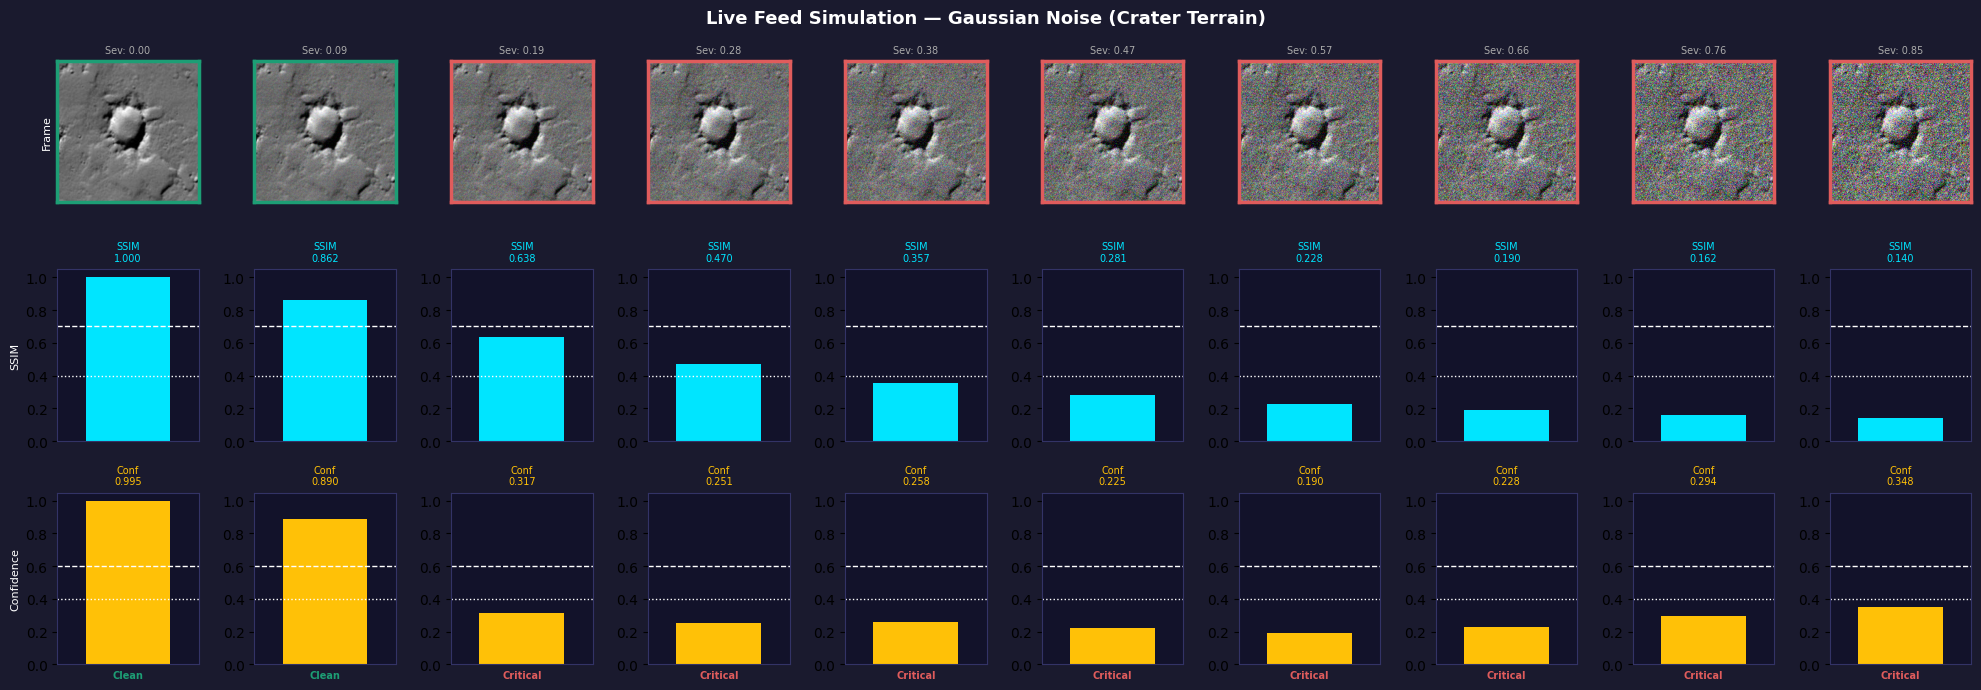

Saved to Drive.


In [ ]:
def simulate_live_feed(clean_frame, degradation_fn, num_frames=10, seed=42):
    """
    Simulate a live camera feed with increasing degradation.
    Monitor assesses each frame and outputs severity + replan decision.
    """
    severities = np.linspace(0, 0.85, num_frames)
    feed_results = []

    for i, sev in enumerate(severities):
        frame = clean_frame if sev == 0 else degradation_fn(clean_frame, severity=sev, seed=seed)
        result = monitor_frame(clean_frame, frame, model, val_transform)
        result['frame_idx'] = i
        result['severity_input'] = round(sev, 3)
        result['frame'] = frame
        feed_results.append(result)

    return feed_results


# Simulate with Gaussian noise on crater terrain
feed = simulate_live_feed(sample_images['crater'], apply_gaussian_noise, num_frames=10)

fig, axes = plt.subplots(3, 10, figsize=(20, 7))
fig.patch.set_facecolor('#1A1A2E')
fig.suptitle('Live Feed Simulation — Gaussian Noise (Crater Terrain)',
             color='white', fontsize=13, fontweight='bold')

for i, r in enumerate(feed):
    col = SEVERITY_COLOURS[r['severity']]

    # Row 1: Frame
    axes[0][i].imshow(r['frame'], cmap='gray')
    axes[0][i].set_title(f'Sev: {r["severity_input"]:.2f}', color='#AAAAAA', fontsize=7)
    axes[0][i].set_xticks([])
    axes[0][i].set_yticks([])
    for spine in axes[0][i].spines.values():
        spine.set_edgecolor(col)
        spine.set_linewidth(2.5)

    # Row 2: SSIM bar
    axes[1][i].bar(0, r['ssim'], color='#00E5FF', width=0.6)
    axes[1][i].axhline(SSIM_CLEAN,    color='white', linestyle='--', linewidth=1)
    axes[1][i].axhline(SSIM_DEGRADED, color='white', linestyle=':',  linewidth=1)
    axes[1][i].set_ylim(0, 1.05)
    axes[1][i].set_xlim(-0.5, 0.5)
    axes[1][i].set_xticks([])
    axes[1][i].set_facecolor('#12122A')
    axes[1][i].set_title(f'SSIM\n{r["ssim"]:.3f}', color='#00E5FF', fontsize=7)
    for spine in axes[1][i].spines.values():
        spine.set_edgecolor('#333366')

    # Row 3: Confidence bar
    axes[2][i].bar(0, r['cnn_confidence'], color='#FFC107', width=0.6)
    axes[2][i].axhline(CONF_CLEAN,    color='white', linestyle='--', linewidth=1)
    axes[2][i].axhline(CONF_DEGRADED, color='white', linestyle=':',  linewidth=1)
    axes[2][i].set_ylim(0, 1.05)
    axes[2][i].set_xlim(-0.5, 0.5)
    axes[2][i].set_xticks([])
    axes[2][i].set_facecolor('#12122A')
    axes[2][i].set_title(f'Conf\n{r["cnn_confidence"]:.3f}', color='#FFC107', fontsize=7)
    status_label = r['severity']
    axes[2][i].set_xlabel(status_label, color=col, fontsize=7, fontweight='bold')
    for spine in axes[2][i].spines.values():
        spine.set_edgecolor('#333366')

axes[0][0].set_ylabel('Frame',      color='white', fontsize=8)
axes[1][0].set_ylabel('SSIM',       color='white', fontsize=8)
axes[2][0].set_ylabel('Confidence', color='white', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Mars Rover Project/figures/nb04_live_feed.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved to Drive.')

##  Step 9 — Save Monitor Configuration to Drive

In [ ]:
import json

monitor_config = {
    'ssim_thresholds': {
        'clean':    SSIM_CLEAN,
        'degraded': SSIM_DEGRADED,
    },
    'confidence_thresholds': {
        'clean':    CONF_CLEAN,
        'degraded': CONF_DEGRADED,
    },
    'trigger_rule': 'EITHER signal below threshold triggers escalation',
    'severity_levels': [CLEAN, DEGRADED, CRITICAL],
    'uncertainty_multipliers': UNCERTAINTY_MULTIPLIER,
}

CONFIG_PATH = '/content/drive/MyDrive/Colab Notebooks/Mars Rover Project/monitor_config.json'
with open(CONFIG_PATH, 'w') as f:
    json.dump(monitor_config, f, indent=2)

print(f'Monitor configuration saved to: {CONFIG_PATH}')
print(json.dumps(monitor_config, indent=2))

Monitor configuration saved to: /content/drive/MyDrive/Colab Notebooks/Mars Rover Project/monitor_config.json
{
  "ssim_thresholds": {
    "clean": 0.7,
    "degraded": 0.4
  },
  "confidence_thresholds": {
    "clean": 0.6,
    "degraded": 0.4
  },
  "trigger_rule": "EITHER signal below threshold triggers escalation",
  "severity_levels": [
    "Clean",
    "Degraded",
    "Critical"
  ],
  "uncertainty_multipliers": {
    "Clean": 1.0,
    "Degraded": 2.0,
    "Critical": 5.0
  }
}



## Summary

- A sensor quality monitor that combines SSIM and CNN confidence into a unified severity classification
- Three severity levels: Clean, Degraded, Critical — each with a defined uncertainty cost multiplier
- Trigger rule: EITHER signal dropping below threshold escalates severity
- Live feed simulation showing the monitor detecting and classifying degradation in real time

The monitor correctly identifies degradation onset and escalation across all three degradation types, with the severity level directly informing the uncertainty multiplier applied to the terrain cost map during replanning.

